# Federated Learning — FMI Temperature Prediction

**Task:** each FMI weather station is a node in an FL network.  
Every node trains a *local linear regression model* that predicts  
**tomorrow's daily maximum temperature** (tmax\_{t+1}) from today's feature vector.

**GTVMin objective:**

$$\min_{w^{(1)},\ldots,w^{(n)}\in\mathbb{R}^d} \sum_{i=1}^{n} \underbrace{\frac{1}{m_i}\|y^{(i)} - X^{(i)}w^{(i)}\|^2}_{L_i(w^{(i)})} + \alpha \sum_{\{i,j\}\in\mathcal{E}} A_{ij}\|w^{(i)}-w^{(j)}\|^2$$

| Step | What we do |
|------|-----------|
| **1. EDA** | Explore the raw FMI dataset |
| **2. Features** | Build per-station (X, y) arrays; chronological split; standardise |
| **3. Graphs** | Four systems compared: A (geo k-NN), B1 (Pearson), B2 (DTW), C (multivariate profile) |
| **4. Baseline** | Per-node OLS (α = 0, no collaboration) |
| **5. Tuning** | Grid-search α for each system using validation MSE |
| **6. Training** | FedGD with theoretically safe step size η |
| **7. Results** | Loss curves, effect of α, predictions vs actuals, final MSE table |

In [1]:
# Install dependencies (run once if dtaidistance is missing)
%pip install dtaidistance --quiet

Note: you may need to restart the kernel to use updated packages.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from functions import (
    load_data, get_station_meta, build_node_datasets,
    chronological_split, standardize_node_datasets,
    build_geo_graph, build_similarity_graph,
    build_dtw_graph, build_multivariate_graph,
    graph_laplacian, graph_info, largest_connected_component,
    mse_loss, local_baseline,
    compute_safe_stepsize, run_fedgd,
    evaluate, tune_alpha, summary_table,
    plot_station_map, plot_graph, plot_loss_curves,
    plot_alpha_tuning, plot_per_station_mse,
)

np.random.seed(42)
DATA_PATH          = "dataFLProject26/daily_records.csv"
WIND_PRESSURE_PATH = "dataFLProject26/daily_wind_pressure.csv"

print("Imports OK")

# Extended feature set (pa_day excluded — too many missing values)
EXTRA_FEATURES = ["tday", "rrday", "snow", "wu_day", "wv_day"]

Imports OK


---
## Stage 1 — Exploratory Data Analysis

Raw data: `daily_records.csv` — 194 FMI stations across Finland, ~40 days of daily `tmin` / `tmax`.

In [32]:
# ── Load data ────────────────────────────────────────────────────────────────
import os
_wp_path = WIND_PRESSURE_PATH if os.path.exists(WIND_PRESSURE_PATH) else None
if _wp_path is None:
    print('[INFO] daily_wind_pressure.csv not found — run GetFMIHourly.py first.')
    print('       Proceeding with baseline features only (tmin, tmax).')

df = load_data(DATA_PATH, wind_pressure_path=_wp_path)

# Drop pa_day — it has many missing values and is excluded from the feature set
if 'pa_day' in df.columns:
    df = df.drop(columns=['pa_day'])

print(f'Shape (before dropna): {df.shape}')
print(f'Stations         : {df["station"].nunique()}')
print(f'Date range       : {df["day"].min().date()}  →  {df["day"].max().date()}')
print(f'Days covered     : {(df["day"].max() - df["day"].min()).days + 1}')
print('\nMissing values (before dropna):')
cols_to_check = [c for c in ['tmax', 'tmin', 'tday', 'rrday', 'snow', 'wu_day', 'wv_day'] if c in df.columns]
print(df[cols_to_check].isnull().sum().to_string())

# Drop all rows that have any NaN in the feature columns
df = df.dropna(subset=cols_to_check).reset_index(drop=True)
print(f'\nShape (after dropna) : {df.shape}')
print(f'Stations remaining   : {df["station"].nunique()}')
print('\nSample rows:')
df.head()

Shape (before dropna): (7680, 12)
Stations         : 192
Date range       : 2026-03-07  →  2026-04-15
Days covered     : 40

Missing values (before dropna):
tmax         0
tmin         0
tday         0
rrday     2920
snow      3183
wu_day    1405
wv_day    1405

Shape (after dropna) : (3220, 12)
Stations remaining   : 81

Sample rows:


,station,lat,lon,day,rrday,snow,tday,tmax,tmin,ws_day,wu_day,wv_day
0,Enontekiö Kilpisjärvi kyläkeskus,69.03905,20.81379,2026-03-07,0.7,92.0,-0.1,3.7,-4.5,5.062500,2.412354,-3.794887
1,Enontekiö Kilpisjärvi kyläkeskus,69.03905,20.81379,2026-03-08,-1.0,87.0,-0.4,3.2,-2.8,1.658333,0.063315,0.256861
2,Enontekiö Kilpisjärvi kyläkeskus,69.03905,20.81379,2026-03-09,7.7,85.0,-5.0,0.4,-13.4,2.091667,-0.547659,1.342699
3,Enontekiö Kilpisjärvi kyläkeskus,69.03905,20.81379,2026-03-10,-1.0,90.0,-2.2,1.9,-7.0,2.112500,-0.015214,0.855603
4,Enontekiö Kilpisjärvi kyläkeskus,69.03905,20.81379,2026-03-11,-1.0,91.0,-4.5,1.4,-12.6,3.316667,-1.946234,2.313051


In [33]:
# ── Check records per station — drop stations with too few rows ───────────────
records_per_station = df.groupby("station").size().sort_values()

print("Stations with fewest raw records:")
print(records_per_station.head(10).to_string())
print()

# 'Pori Isomaki' has only 4 rows — far too few for a meaningful train/val/test
# split (with 60/20/20: ~1 train point, 0 val points, OLS is ill-posed).
# We remove it from df entirely before any further processing.
STATIONS_TO_DROP = [s for s in records_per_station.index if records_per_station[s] < 30]
print(f"Dropping {len(STATIONS_TO_DROP)} station(s) with < 30 raw records: {STATIONS_TO_DROP}")
df = df[~df["station"].isin(STATIONS_TO_DROP)].reset_index(drop=True)
print(f"Remaining stations: {df['station'].nunique()}")

Stations with fewest raw records:
station
Ylivieska lentokenttä        27
Turku Artukainen             36
Ilomantsi Mekrijärvi         37
Savukoski Tulppio            40
Salo Kiikala lentokenttä     40
Salla kirkonkylä             40
Salla Naruska                40
Rovaniemi lentoasema AWOS    40
Rovaniemi Apukka             40
Rautavaara Ylä-Luosta        40

Dropping 1 station(s) with < 30 raw records: ['Ylivieska lentokenttä']
Remaining stations: 80


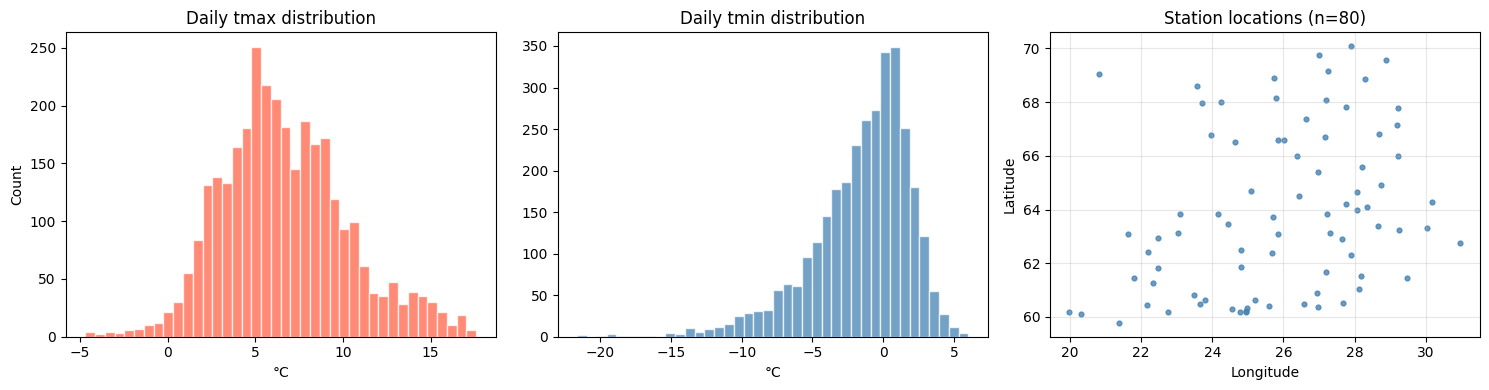

tmax range: -4.7 to 17.6 °C
tmin range: -21.6 to 6.0 °C


In [34]:
# ── Temperature distributions and geographic scatter ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of tmax
axes[0].hist(df["tmax"].dropna(), bins=40, color="tomato", alpha=0.75, edgecolor="white")
axes[0].set_title("Daily tmax distribution")
axes[0].set_xlabel("°C")
axes[0].set_ylabel("Count")

# Distribution of tmin
axes[1].hist(df["tmin"].dropna(), bins=40, color="steelblue", alpha=0.75, edgecolor="white")
axes[1].set_title("Daily tmin distribution")
axes[1].set_xlabel("°C")

# Geographic scatter of all stations
meta = get_station_meta(df)
axes[2].scatter(meta["lon"], meta["lat"], s=12, c="steelblue", alpha=0.8)
axes[2].set_title(f"Station locations (n={len(meta)})")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"tmax range: {df['tmax'].min():.1f} to {df['tmax'].max():.1f} °C")
print(f"tmin range: {df['tmin'].min():.1f} to {df['tmin'].max():.1f} °C")

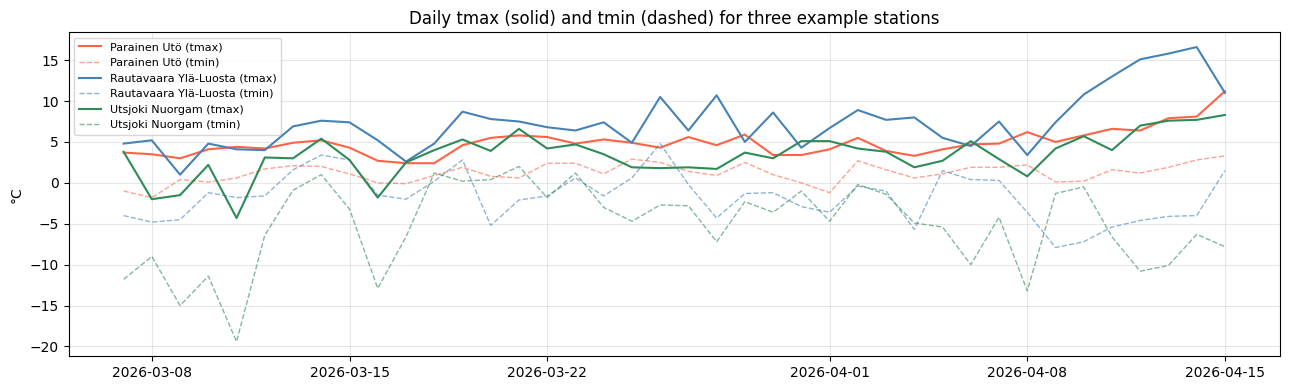

In [35]:
# ── Temperature time series: a few example stations ─────────────────────────
example_stations = ["Helsinki Kaisaniemi", "Sodankylä", "Rovaniemi lentoasema"]
example_stations = [s for s in example_stations if s in df["station"].values]

if len(example_stations) < 3:
    meta_sorted = get_station_meta(df).sort_values("lat")
    example_stations = [
        meta_sorted.iloc[0]["station"],
        meta_sorted.iloc[len(meta_sorted) // 2]["station"],
        meta_sorted.iloc[-1]["station"],
    ]

colors = ["tomato", "steelblue", "seagreen"]
fig, ax = plt.subplots(figsize=(13, 4))
for sname, color in zip(example_stations, colors):
    sub = df[df["station"] == sname].sort_values("day")
    ax.plot(sub["day"], sub["tmax"], label=f"{sname} (tmax)", color=color, linewidth=1.5)
    ax.plot(sub["day"], sub["tmin"], label=f"{sname} (tmin)", color=color, linewidth=1, linestyle="--", alpha=0.6)
ax.set_title("Daily tmax (solid) and tmin (dashed) for three example stations")
ax.set_ylabel("°C")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Stage 2 — Feature Engineering

**Why linear regression?**  
Each node has roughly 23 training points and 8 features.  
A linear model is:
- *Underpinned by physics*: tomorrow's max temperature correlates strongly with today's temps and atmospheric state.
- *Safe from overfitting*: with m ≈ 23 training points, a non-linear model would overfit hopelessly.
- *Analytically tractable*: the loss is convex and smooth → FedGD converges provably.
- *Efficient for FL*: the gradient is closed-form and FedRelax reduces to ridge regression.

**Feature vector (extended):**  
$x^{(i,t)} = [1,\ \text{tmin}_t,\ \text{tmax}_t,\ \text{tday}_t,\ \text{rrday}_t,\ \text{snow}_t,\ w^u_t,\ w^v_t]^\top \in \mathbb{R}^8$

where $w^u_t, w^v_t$ are the eastward/northward daily-mean wind speed components  
(vector decomposition of wind direction to handle circular statistics).  
Sea-level pressure (`pa_day`) was excluded — it has too many missing values across stations.

**Feature standardisation:** each feature is z-score normalised *per station* on the training set:
$$\tilde{x}_k^{(i)} = \frac{x_k^{(i)} - \mu_k^{(i,\text{train})}}{\sigma_k^{(i,\text{train})}}$$
The same mean and std are applied to val/test to avoid data leakage.

**Label:** $y^{(i,t)} = \text{tmax}_{t+1}$  
**Chronological split:** first 60% → train, next 20% → val, last 20% → test  
(Random shuffling is *not* valid for time-series data.)

In [36]:
# ── Build per-station datasets ───────────────────────────────────────────────
# Use extended features when wind/pressure data was loaded successfully
_extra = EXTRA_FEATURES if _wp_path is not None else ["tday", "rrday", "snow"]
_extra = [f for f in _extra if f in df.columns]  # guard against missing cols

NODE_DATASETS = build_node_datasets(df, min_points=30, extra_features=_extra)
NODE_DATASETS = chronological_split(NODE_DATASETS, train_frac=0.60, val_frac=0.20)
NODE_DATASETS = standardize_node_datasets(NODE_DATASETS)

ALL_NAMES = sorted(NODE_DATASETS.keys())

print(f"Stations with ≥ 30 consecutive data points: {len(ALL_NAMES)}")

# Inspect one example station
ex_name = ALL_NAMES[0]
ex = NODE_DATASETS[ex_name]
print(f"\nExample station: '{ex_name}'")
print(f"  Total pairs     : {len(ex['y'])}")
print(f"  Train / Val / Test: {len(ex['train_idx'])} / {len(ex['val_idx'])} / {len(ex['test_idx'])}")
print(f"  X shape         : {ex['X_std'].shape}   (feature names: {ex['feature_names']})")
print(f"  y range         : [{ex['y'].min():.1f}, {ex['y'].max():.1f}] °C")


Stations with ≥ 30 consecutive data points: 80

Example station: 'Enontekiö Kilpisjärvi kyläkeskus'
  Total pairs     : 39
  Train / Val / Test: 23 / 7 / 9
  X shape         : (39, 8)   (feature names: ['bias', 'tmin', 'tmax', 'tday', 'rrday', 'snow', 'wu_day', 'wv_day'])
  y range         : [-3.1, 6.7] °C


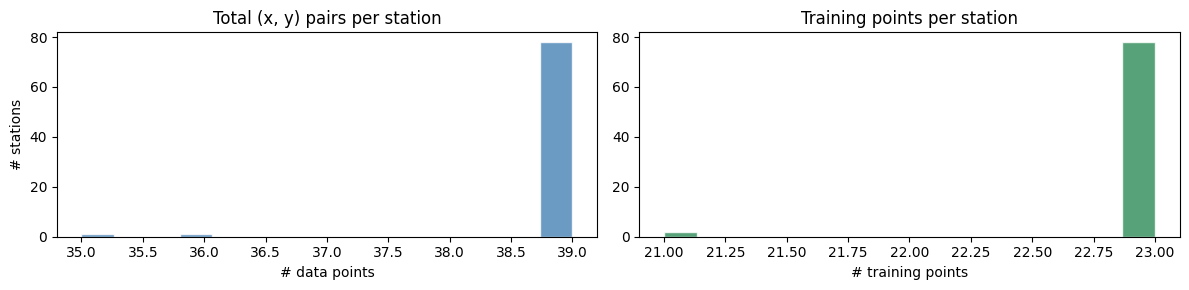

Median training size: 23 points — small, which motivates FL collaboration.


In [37]:
# ── Dataset size distribution ─────────────────────────────────────────────────
m_vals = [len(NODE_DATASETS[n]["y"]) for n in ALL_NAMES]
m_train = [len(NODE_DATASETS[n]["train_idx"]) for n in ALL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(m_vals, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Total (x, y) pairs per station")
axes[0].set_xlabel("# data points")
axes[0].set_ylabel("# stations")

axes[1].hist(m_train, bins=15, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].set_title("Training points per station")
axes[1].set_xlabel("# training points")
plt.tight_layout()
plt.show()

print(f"Median training size: {np.median(m_train):.0f} points — small, which motivates FL collaboration.")

---
## Stage 3 — Graph Construction

We compare **four structurally different** FL network designs.  
All four are evaluated on the same shared set of stations (intersection of all LCCs) to ensure fair comparison.

### System A — Geographic k-NN graph
Connect each station to its **k geographically closest** neighbours (Haversine distance).  
Edge weight: $A_{ij} = \exp\!\left(-d_{ij}^2 / 2\sigma^2\right)$, $\sigma$ = median pairwise distance.  
*Rationale:* nearby stations share microclimates → similar optimal models.

### System B1 — Pearson correlation graph
Connect stations $i,j$ if $\text{corr}(y_{\text{train}}^{(i)}, y_{\text{train}}^{(j)}) \geq \tau$.  
Edge weight: $A_{ij} = \text{corr}(\cdot)$.  
*Rationale:* correlated temperature time series reflect common synoptic patterns.

### System B2 — DTW similarity graph
Compute pairwise **Dynamic Time Warping** distance between z-score-normalised training $y$ series.  
Convert to weight via RBF: $A_{ij} = \exp\!\left(-d_{\text{DTW},ij}^2 / \sigma^2\right)$, keep edges where weight $\geq \tau$.  
*Rationale:* DTW captures shape similarity even under temporal shifts — stronger than Pearson when weather systems arrive at different times in different regions.

### System C — Multivariate climate-profile graph
For each station compute $\mu^{(i)} = \frac{1}{|\mathcal{T}_{\text{train}}|}\sum_{t \in \mathcal{T}_{\text{train}}} x_t^{(i)} \in \mathbb{R}^{d-1}$ (mean of all features except intercept, on training data).  
Connect each station to its **k nearest neighbours** in this profile space (Euclidean distance after global z-score normalisation, RBF weight).  
*Rationale:* stations with similar climate regime (cold/warm, windy/calm, snowy/dry) share structural patterns in their linear models — regardless of physical distance.

### Hyperparameter selection
For each system, the graph hyperparameter ($k$ or $\tau$) is chosen **data-driven**:
- Disconnected graphs are skipped immediately (a disconnected graph cannot propagate information across all nodes).
- For each remaining connected candidate, a short FedGD + α grid-search is run and the **validation MSE** is recorded.
- The hyperparameter with the **lowest validation MSE** is selected.


In [38]:
# ── System A: geographic k-NN — select k by validation MSE ──────────────────
stations_list = [NODE_DATASETS[n] for n in ALL_NAMES]

_SWEEP_ALPHA  = [1e-2, 1e-1, 1.0, 10.0]
_SWEEP_N_ITER = 200

print("System A — geographic k-NN sweep (k ∈ {2, 3, 4, 5, 6, 7, 8}):")
print(f"{'k':>3}  {'edges':>6}  {'connected':>9}  {'lambda_2':>8}  {'best_alpha':>10}  {'val_MSE':>8}")

_sys_A_results = {}
for k in [2, 3, 4, 5, 6, 7, 8]:
    A_tmp = build_geo_graph(stations_list, k=k)
    info  = graph_info(A_tmp)
    if not info["is_connected"]:
        print(f"{k:>3}  {info['n_edges']:>6}  {'False':>9}  {info['lambda_2']:>8.4f}  {'—':>10}  {'—':>8}")
        continue
    best_a, val_mses = tune_alpha(
        NODE_DATASETS, ALL_NAMES, A_tmp,
        alpha_grid=_SWEEP_ALPHA, n_iter=_SWEEP_N_ITER
    )
    best_val = min(val_mses)
    _sys_A_results[k] = {"A": A_tmp, "best_alpha": best_a, "val_mse": best_val, "info": info}
    print(f"{k:>3}  {info['n_edges']:>6}  {'True':>9}  {info['lambda_2']:>8.4f}  {best_a:>10.4g}  {best_val:>8.4f}")

K_GEO = min(_sys_A_results, key=lambda k: _sys_A_results[k]["val_mse"])
print(f"\n→ Selected K_GEO = {K_GEO}  (val MSE = {_sys_A_results[K_GEO]['val_mse']:.4f})")


System A — geographic k-NN sweep (k ∈ {2, 3, 4, 5, 6, 7, 8}):
  k   edges  connected  lambda_2  best_alpha   val_MSE
  2     101      False   -0.0000           —         —
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.7200
  α=0.1  →  val MSE=5.2070
  α=1  →  val MSE=4.7758
  α=10  →  val MSE=4.9211
  → best α = 1.0
  3     152       True    0.0159           1    4.7758
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.6644
  α=0.1  →  val MSE=5.0775
  α=1  →  val MSE=4.7191
  α=10  →  val MSE=5.4141
  → best α = 1.0
  4     199       True    0.0412           1    4.7191
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.6065
  α=0.1  →  val MSE=4.9641
  α=1  →  val MSE=4.6623
  α=10  →  val MSE=6.1789
  → best α = 1.0
  5     241       True    0.0592           1    4.6623
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.5394
  α=0.1  →  val MSE=4.8748
  α=1  →  val MSE=4.6344
  α=10  →  val MSE=7.5580
  → best α = 1.0
  6     291       True    0.0776           1    4.6344


In [39]:
# ── System A: build final graph with selected K_GEO ──────────────────────────
A_GEO_ALL = _sys_A_results[K_GEO]["A"]

info_geo_all = graph_info(A_GEO_ALL)
print(f"System A (k={K_GEO}):")
for key, val in info_geo_all.items():
    print(f"  {key:15}: {val}")


System A (k=7):
  n_nodes        : 80
  n_edges        : 339
  density        : 0.1073
  degree_min     : 6.088424540751756
  degree_max     : 13.4505723907433
  degree_mean    : 8.170286558276018
  lambda_2       : 0.09632951697834698
  lambda_max     : 14.71993678965401
  n_components   : 1
  is_connected   : True


In [40]:
# ── System B1: Pearson correlation — select threshold by validation MSE ───────
# Pearson graphs are threshold-based: full connectivity on ALL_NAMES is rarely
# achievable (a few offshore islands are always isolated at high thresholds).
# We therefore evaluate each candidate on its LCC, and require LCC ≥ 80% of
# ALL_NAMES to ensure we are not comparing very different node sets.

_MIN_LCC_FRAC = 0.80   # require at least 80 % of stations in the LCC

print("System B1 — Pearson similarity sweep (thr ∈ {0.6, 0.7, 0.8, 0.9}):")
print(f"{'thr':>5}  {'edges':>6}  {'LCC size':>8}  {'connected':>9}  {'best_alpha':>10}  {'val_MSE':>8}")

_sys_B1_results = {}
for thr in [0.6, 0.7, 0.8, 0.9]:
    A_tmp = build_similarity_graph(NODE_DATASETS, ALL_NAMES, threshold=thr)
    info  = graph_info(A_tmp)
    A_lcc, lcc_names = largest_connected_component(A_tmp, ALL_NAMES)
    lcc_frac = len(lcc_names) / len(ALL_NAMES)
    if lcc_frac < _MIN_LCC_FRAC:
        print(f"{thr:>5.1f}  {info['n_edges']:>6}  {len(lcc_names):>8}  {'False':>9}  {'—':>10}  {'—':>8}  (LCC too small: {lcc_frac:.0%})")
        continue
    # Evaluate tune_alpha on the LCC
    best_a, val_mses = tune_alpha(
        NODE_DATASETS, lcc_names, A_lcc,
        alpha_grid=_SWEEP_ALPHA, n_iter=_SWEEP_N_ITER
    )
    best_val = min(val_mses)
    _sys_B1_results[thr] = {
        "A_full": A_tmp, "A_lcc": A_lcc, "lcc_names": lcc_names,
        "best_alpha": best_a, "val_mse": best_val, "info": info,
    }
    connected_label = "True" if info["is_connected"] else f"LCC={len(lcc_names)}"
    print(f"{thr:>5.1f}  {info['n_edges']:>6}  {len(lcc_names):>8}  {connected_label:>9}  {best_a:>10.4g}  {best_val:>8.4f}")

if _sys_B1_results:
    THR_B1 = min(_sys_B1_results, key=lambda t: _sys_B1_results[t]["val_mse"])
    print(f"\n→ Selected THR_B1 = {THR_B1}  (val MSE = {_sys_B1_results[THR_B1]['val_mse']:.4f})")
else:
    THR_B1 = 0.8
    print(f"\n→ No valid candidate found; falling back to THR_B1 = {THR_B1}")


System B1 — Pearson similarity sweep (thr ∈ {0.6, 0.7, 0.8, 0.9}):
  thr   edges  LCC size  connected  best_alpha   val_MSE
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.3420
  α=0.1  →  val MSE=5.5892
  α=1  →  val MSE=6.6626
  α=10  →  val MSE=21.9733
  → best α = 0.01
  0.6    1183        78     LCC=78        0.01    5.3420
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.4238
  α=0.1  →  val MSE=5.3255
  α=1  →  val MSE=6.1330
  α=10  →  val MSE=19.3876
  → best α = 0.1
  0.7     765        78     LCC=78         0.1    5.3255
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.7025
  α=0.1  →  val MSE=5.2611
  α=1  →  val MSE=5.2160
  α=10  →  val MSE=12.0545
  → best α = 1.0
  0.8     381        76     LCC=76           1    5.2160
  0.9     101        25      False           —         —  (LCC too small: 31%)

→ Selected THR_B1 = 0.8  (val MSE = 5.2160)


In [41]:
# ── System B1: build final graph with selected THR_B1 ────────────────────────
if _sys_B1_results:
    A_B1_FULL  = _sys_B1_results[THR_B1]["A_full"]
    A_B1_SUB   = _sys_B1_results[THR_B1]["A_lcc"]
    B1_NAMES   = _sys_B1_results[THR_B1]["lcc_names"]
else:
    A_B1_FULL = build_similarity_graph(NODE_DATASETS, ALL_NAMES, threshold=THR_B1)
    A_B1_SUB, B1_NAMES = largest_connected_component(A_B1_FULL, ALL_NAMES)

info_b1 = graph_info(A_B1_SUB)
print(f"System B1 (Pearson thr={THR_B1}, LCC):")
for key, val in info_b1.items():
    print(f"  {key:15}: {val}")
print(f"\nLCC size: {len(B1_NAMES)} stations")


System B1 (Pearson thr=0.8, LCC):
  n_nodes        : 76
  n_edges        : 380
  density        : 0.1333
  degree_min     : 0.8959712314289278
  degree_max     : 18.954744502126314
  degree_mean    : 8.70412406762815
  lambda_2       : 0.09162484183761523
  lambda_max     : 20.38999877807352
  n_components   : 1
  is_connected   : True

LCC size: 76 stations


In [42]:
# ── System B2: DTW similarity — select threshold by validation MSE ────────────
print("System B2 — DTW similarity sweep (thr ∈ {0.3, 0.5, 0.7}):")
print(f"{'thr':>5}  {'edges':>6}  {'LCC size':>8}  {'connected':>9}  {'best_alpha':>10}  {'val_MSE':>8}")

_sys_B2_results = {}
for thr in [0.3, 0.5, 0.7]:
    A_tmp = build_dtw_graph(NODE_DATASETS, ALL_NAMES, threshold=thr)
    info  = graph_info(A_tmp)
    _, lcc = largest_connected_component(A_tmp, ALL_NAMES)
    if not info["is_connected"]:
        print(f"{thr:>5.1f}  {info['n_edges']:>6}  {len(lcc):>8}  {'False':>9}  {'—':>10}  {'—':>8}")
        continue
    best_a, val_mses = tune_alpha(
        NODE_DATASETS, ALL_NAMES, A_tmp,
        alpha_grid=_SWEEP_ALPHA, n_iter=_SWEEP_N_ITER
    )
    best_val = min(val_mses)
    _sys_B2_results[thr] = {"A": A_tmp, "best_alpha": best_a, "val_mse": best_val, "info": info, "lcc": lcc}
    print(f"{thr:>5.1f}  {info['n_edges']:>6}  {len(lcc):>8}  {'True':>9}  {best_a:>10.4g}  {best_val:>8.4f}")

if _sys_B2_results:
    THR_B2 = min(_sys_B2_results, key=lambda t: _sys_B2_results[t]["val_mse"])
    print(f"\n→ Selected THR_B2 = {THR_B2}  (val MSE = {_sys_B2_results[THR_B2]['val_mse']:.4f})")
else:
    THR_B2 = 0.5
    print(f"\n→ No connected graph found; falling back to THR_B2 = {THR_B2}")

# ── System C: multivariate profile — select k by validation MSE ──────────────
print("\nSystem C — Multivariate profile sweep (k ∈ {3, 5, 8}):")
print(f"{'k':>4}  {'edges':>6}  {'components':>10}  {'connected':>9}  {'best_alpha':>10}  {'val_MSE':>8}")

_sys_C_results = {}
for k in [3, 5, 8]:
    A_tmp = build_multivariate_graph(NODE_DATASETS, ALL_NAMES, k=k)
    info  = graph_info(A_tmp)
    if not info["is_connected"]:
        print(f"{k:>4}  {info['n_edges']:>6}  {info['n_components']:>10}  {'False':>9}  {'—':>10}  {'—':>8}")
        continue
    best_a, val_mses = tune_alpha(
        NODE_DATASETS, ALL_NAMES, A_tmp,
        alpha_grid=_SWEEP_ALPHA, n_iter=_SWEEP_N_ITER
    )
    best_val = min(val_mses)
    _sys_C_results[k] = {"A": A_tmp, "best_alpha": best_a, "val_mse": best_val, "info": info}
    print(f"{k:>4}  {info['n_edges']:>6}  {info['n_components']:>10}  {'True':>9}  {best_a:>10.4g}  {best_val:>8.4f}")

if _sys_C_results:
    K_C = min(_sys_C_results, key=lambda k: _sys_C_results[k]["val_mse"])
    print(f"\n→ Selected K_C = {K_C}  (val MSE = {_sys_C_results[K_C]['val_mse']:.4f})")
else:
    K_C = 5
    print(f"\n→ No connected graph found; falling back to K_C = {K_C}")

# ── Build B2 and C graphs ─────────────────────────────────────────────────────
A_B2_FULL = (
    _sys_B2_results[THR_B2]["A"]
    if _sys_B2_results
    else build_dtw_graph(NODE_DATASETS, ALL_NAMES, threshold=THR_B2)
)
_, B2_NAMES = largest_connected_component(A_B2_FULL, ALL_NAMES)
print(f"\nSystem B2 (DTW thr={THR_B2}) LCC: {len(B2_NAMES)} stations")

A_C_ALL = (
    _sys_C_results[K_C]["A"]
    if _sys_C_results
    else build_multivariate_graph(NODE_DATASETS, ALL_NAMES, k=K_C)
)
print(f"System C (multivariate k={K_C}): connected={graph_info(A_C_ALL)['is_connected']}")

# ── Shared node set: iterative intersection until all graphs are connected ────
# Start with intersection of B1 LCC and B2 LCC (A and C are always connected).
# Then, restrict all graphs to the candidate shared set and take LCCs of any
# disconnected graphs — repeat until stable.

candidate = set(B1_NAMES) & set(B2_NAMES)

for _iter in range(5):   # at most 5 refinement rounds
    cand_list  = sorted(candidate)
    cand_idx   = [ALL_NAMES.index(n) for n in cand_list]

    A_GEO_c = A_GEO_ALL[np.ix_(cand_idx, cand_idx)]
    A_B1_c  = A_B1_FULL[np.ix_(cand_idx, cand_idx)]
    A_B2_c  = A_B2_FULL[np.ix_(cand_idx, cand_idx)]
    A_C_c   = A_C_ALL[np.ix_(cand_idx, cand_idx)]

    new_candidate = set(cand_list)
    for A_mat, names_ref in [(A_GEO_c, cand_list), (A_B1_c, cand_list),
                              (A_B2_c, cand_list),  (A_C_c,  cand_list)]:
        if not graph_info(A_mat)["is_connected"]:
            _, lcc_names = largest_connected_component(A_mat, names_ref)
            new_candidate &= set(lcc_names)

    if new_candidate == candidate:
        break
    candidate = new_candidate

SHARED_NAMES = sorted(candidate)
shared_idx   = [ALL_NAMES.index(n) for n in SHARED_NAMES]

A_GEO = A_GEO_ALL[np.ix_(shared_idx, shared_idx)]
A_B1  = A_B1_FULL[np.ix_(shared_idx, shared_idx)]
A_B2  = A_B2_FULL[np.ix_(shared_idx, shared_idx)]
A_C   = A_C_ALL[np.ix_(shared_idx, shared_idx)]

print(f"\nShared node set: {len(SHARED_NAMES)} stations (after connectivity refinement)")
for sys_name, A_mat in [("A  (geo k-NN)", A_GEO), ("B1 (Pearson)", A_B1),
                         ("B2 (DTW)",      A_B2),  ("C  (profile)", A_C)]:
    info = graph_info(A_mat)
    print(f"  {sys_name}: {info['n_nodes']} nodes, {info['n_edges']} edges, "
          f"connected={info['is_connected']}, λ₂={info['lambda_2']:.4f}")


The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternat

System B2 — DTW similarity sweep (thr ∈ {0.3, 0.5, 0.7}):
  thr   edges  LCC size  connected  best_alpha   val_MSE


The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternat

Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.1609
  α=0.1  →  val MSE=5.8034


The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternat

  α=1  →  val MSE=6.8715
  α=10  →  val MSE=20.4058
  → best α = 0.01
  0.3    2169        80       True        0.01    5.1609


The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternat

  0.5     657        79      False           —         —


The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.
The compiled dtaidistance C library is not available.
See the documentation for alternat

  0.7     110        49      False           —         —

→ Selected THR_B2 = 0.3  (val MSE = 5.1609)

System C — Multivariate profile sweep (k ∈ {3, 5, 8}):
   k   edges  components  connected  best_alpha   val_MSE
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.6530
  α=0.1  →  val MSE=5.0100
  α=1  →  val MSE=4.5568
  α=10  →  val MSE=5.1015
  → best α = 1.0
   3     166           1       True           1    4.5568
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.5323
  α=0.1  →  val MSE=4.8366
  α=1  →  val MSE=4.4835
  α=10  →  val MSE=7.6599
  → best α = 1.0
   5     267           1       True           1    4.4835
Tuning α  (algorithm=fedgd):
  α=0.01  →  val MSE=5.3618
  α=0.1  →  val MSE=4.6693
  α=1  →  val MSE=4.5005
  α=10  →  val MSE=11.6208
  → best α = 1.0
   8     441           1       True           1    4.5005

→ Selected K_C = 5  (val MSE = 4.4835)

System B2 (DTW thr=0.3) LCC: 80 stations
System C (multivariate k=5): connected=True

Shared node set: 76 statio

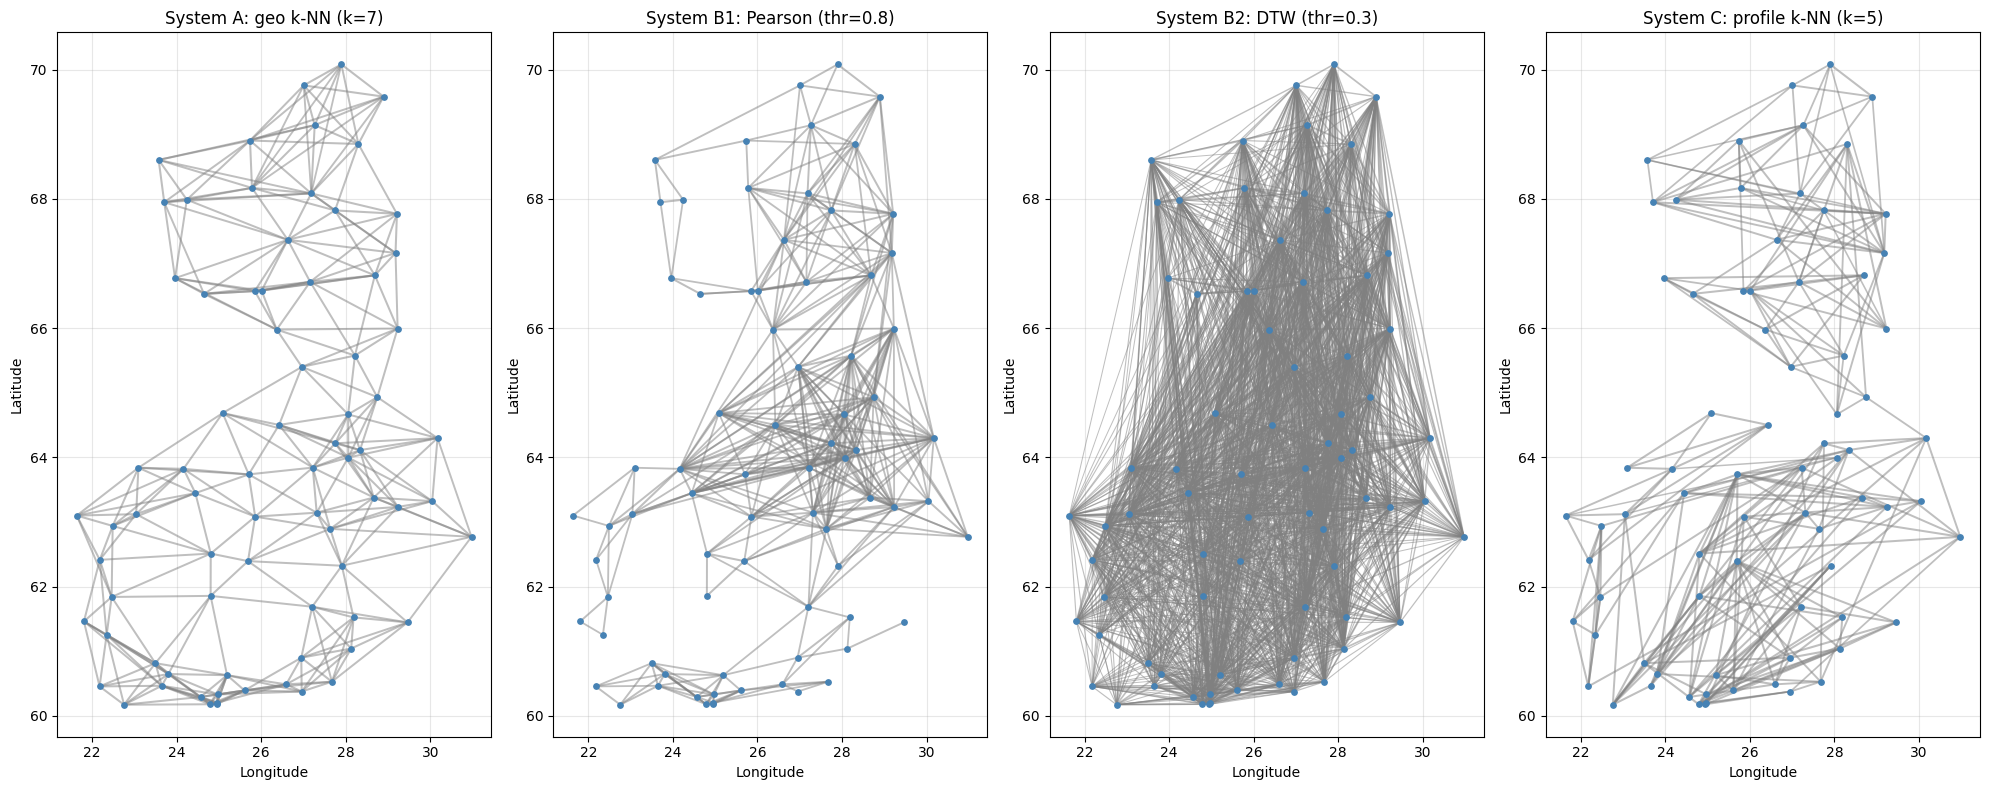

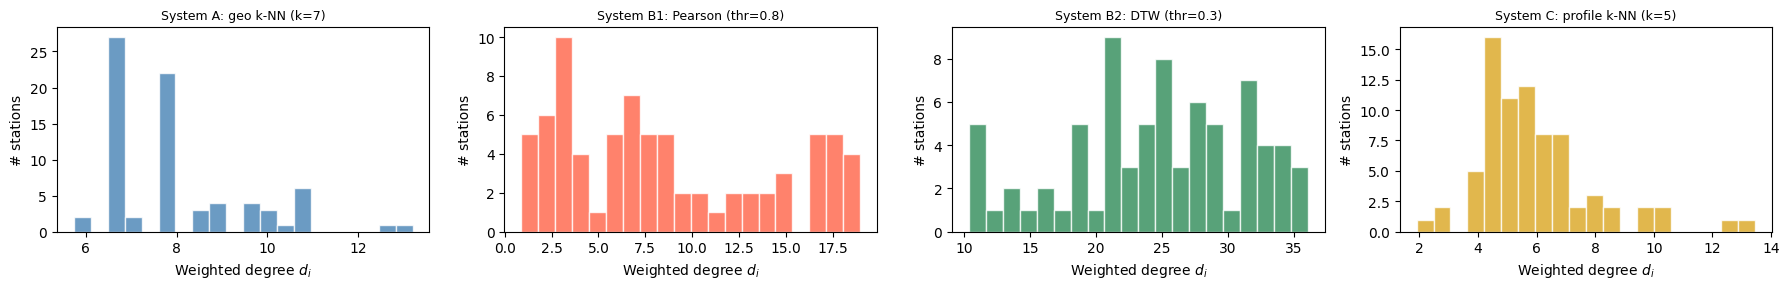

In [43]:
# ── Graph visualisation: all four systems ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

configs = [
    (A_GEO, f"System A: geo k-NN (k={K_GEO})"),
    (A_B1,  f"System B1: Pearson (thr={THR_B1})"),
    (A_B2,  f"System B2: DTW (thr={THR_B2})"),
    (A_C,   f"System C: profile k-NN (k={K_C})"),
]

for ax, (A, title) in zip(axes, configs):
    plot_graph(NODE_DATASETS, SHARED_NAMES, A, title=title, ax=ax)

plt.tight_layout()
plt.show()

# Degree distribution comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 3))
colors = ["steelblue", "tomato", "seagreen", "goldenrod"]
for ax, (A, title), color in zip(axes, configs, colors):
    deg = A.sum(axis=1)
    ax.hist(deg, bins=20, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Weighted degree $d_i$")
    ax.set_ylabel("# stations")
plt.tight_layout()
plt.show()

---
## Stage 4 — Local Baseline (α = 0)

Before adding FL collaboration, we compute the **ordinary least-squares (OLS) solution independently at each node**.  
This corresponds to GTVMin with α = 0 (no graph regularisation).

The closed-form solution is $\hat{w}^{(i)} = (X_{\text{train}}^{(i)\top} X_{\text{train}}^{(i)})^{-1} X_{\text{train}}^{(i)\top} y_{\text{train}}^{(i)}$.

This baseline is the *target to beat* — if FL fails to improve on it, the graph design or regularisation parameter is wrong.

In [44]:
# ── OLS baseline (closed-form) ───────────────────────────────────────────────
W_baseline = local_baseline(NODE_DATASETS, SHARED_NAMES)
ev_baseline = evaluate(W_baseline, NODE_DATASETS, SHARED_NAMES)

print("Local OLS baseline (α = 0):  no FL collaboration")
print(f"  Mean train MSE : {ev_baseline['train_mse'].mean():.4f} °C²")
print(f"  Mean val   MSE : {ev_baseline['val_mse'].mean():.4f}  °C²")
print(f"  Mean test  MSE : {ev_baseline['test_mse'].mean():.4f}  °C²")
print()

# The large gap between train and test suggests that the temperature regime
# shifts over the 40-day window (winter → early spring), and each station
# needs more data or cross-station information to generalise.
print("Note: large train→test gap is expected — the 40-day window spans the")
print("transition from deep winter to early spring in Finland.")

Local OLS baseline (α = 0):  no FL collaboration
  Mean train MSE : 2.3906 °C²
  Mean val   MSE : 6.4027  °C²
  Mean test  MSE : 49.2572  °C²

Note: large train→test gap is expected — the 40-day window spans the
transition from deep winter to early spring in Finland.


---
## Stage 5 — Hyperparameter Tuning

### 5.1 Step size η (FedGD)

From Lecture 3, the gradient-descent operator is non-expansive when:

$$\eta \leq \frac{1}{\max_i \left(\beta_i + 2\alpha\, d_i\right)}, \qquad \beta_i = \frac{2\,\lambda_{\max}(X_i^\top X_i)}{m_i}$$

This step size is recomputed **per system per α** inside `compute_safe_stepsize`.

### 5.2 Regularisation α

Grid-search $\alpha \in \{10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}$ for each system using **validation MSE**.  
- Small α ≈ independent local models (baseline)  
- Large α ≈ single global shared model  
- Optimal α is somewhere between the two extremes

System A — geographic k-NN graph
Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=6.2056
  α=0.01  →  val MSE=5.7304
  α=0.1  →  val MSE=5.0095
  α=1  →  val MSE=4.8203
  α=10  →  val MSE=5.5843
  → best α = 1.0


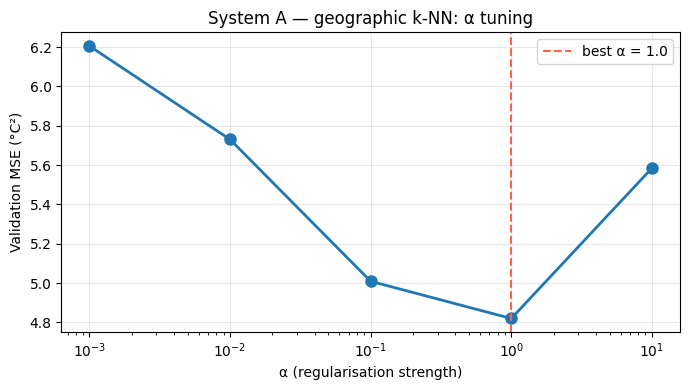

In [45]:
# ── Alpha tuning — System A (geographic) ─────────────────────────────────────
ALPHA_GRID   = [1e-3, 1e-2, 1e-1, 1.0, 10.0]
N_ITER_TUNE  = 400

print("=" * 55)
print("System A — geographic k-NN graph")
print("=" * 55)
best_alpha_A, val_mses_A = tune_alpha(
    NODE_DATASETS, SHARED_NAMES, A_GEO,
    alpha_grid=ALPHA_GRID, n_iter=N_ITER_TUNE, algorithm="fedgd"
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_alpha_tuning(ALPHA_GRID, val_mses_A, best_alpha_A,
                  title="System A — geographic k-NN: α tuning", ax=ax)
plt.tight_layout()
plt.show()

System B1 (Pearson correlation)
Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=6.2147
  α=0.01  →  val MSE=5.8366
  α=0.1  →  val MSE=5.3835
  α=1  →  val MSE=5.3525
  α=10  →  val MSE=7.4088
  → best α = 1.0
System B2 (DTW similarity)
Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=6.0039
  α=0.01  →  val MSE=5.3567
  α=0.1  →  val MSE=5.9768
  α=1  →  val MSE=7.0232
  α=10  →  val MSE=12.2458
  → best α = 0.01
System C  (climate profile)
Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=6.2199
  α=0.01  →  val MSE=5.7875
  α=0.1  →  val MSE=5.0267
  α=1  →  val MSE=4.6558
  α=10  →  val MSE=5.0367
  → best α = 1.0


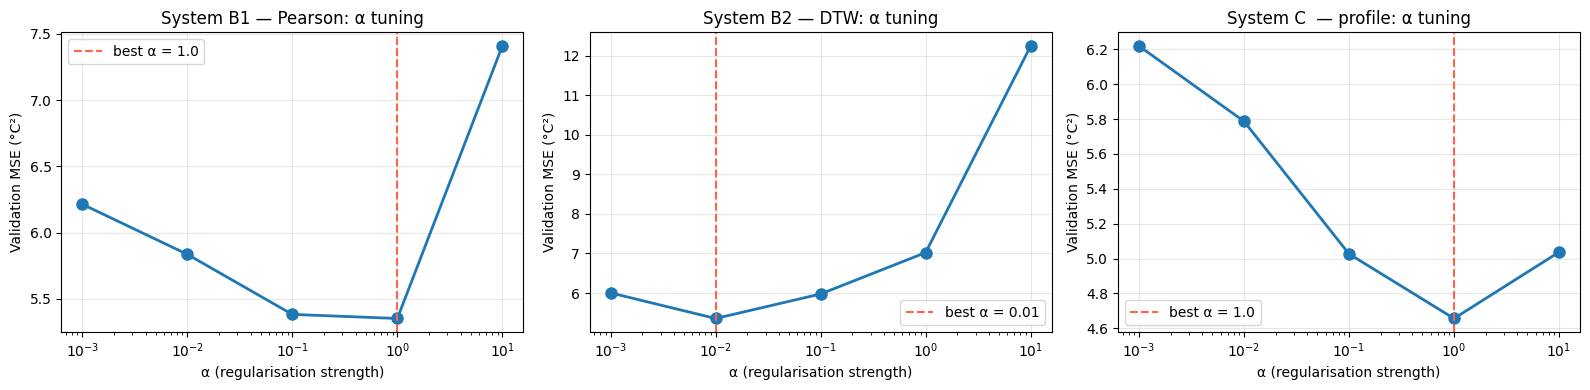


Best α summary:
  System A  : 1.0
  System B1 : 1.0
  System B2 : 0.01
  System C  : 1.0


In [46]:
# ── Alpha tuning — System B1 (Pearson), B2 (DTW), C (profile) ────────────────
for sys_name, A_mat in [
    ("B1 (Pearson correlation)", A_B1),
    ("B2 (DTW similarity)",      A_B2),
    ("C  (climate profile)",     A_C),
]:
    print("=" * 55)
    print(f"System {sys_name}")
    print("=" * 55)
    best, mses = tune_alpha(
        NODE_DATASETS, SHARED_NAMES, A_mat,
        alpha_grid=ALPHA_GRID, n_iter=N_ITER_TUNE, algorithm="fedgd"
    )
    if sys_name.startswith("B1"):
        best_alpha_B1, val_mses_B1 = best, mses
    elif sys_name.startswith("B2"):
        best_alpha_B2, val_mses_B2 = best, mses
    else:
        best_alpha_C,  val_mses_C  = best, mses

# Summary plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, mses, best) in zip(axes, [
    ("System B1 — Pearson", val_mses_B1, best_alpha_B1),
    ("System B2 — DTW",     val_mses_B2, best_alpha_B2),
    ("System C  — profile", val_mses_C,  best_alpha_C),
]):
    plot_alpha_tuning(ALPHA_GRID, mses, best, title=f"{title}: α tuning", ax=ax)
plt.tight_layout()
plt.show()

print(f"\nBest α summary:")
print(f"  System A  : {best_alpha_A}")
print(f"  System B1 : {best_alpha_B1}")
print(f"  System B2 : {best_alpha_B2}")
print(f"  System C  : {best_alpha_C}")

---
## Stage 6 — FedGD Training

**FedGD update** (synchronous, Lecture 4):

$$w^{(i,t+1)} = w^{(i,t)} - \eta \left[ \nabla L_i(w^{(i,t)}) + 2\alpha \sum_{j \in \mathcal{N}(i)} A_{ij}(w^{(i,t)} - w^{(j,t)}) \right]$$

Step size $\eta = 1/\max_i(\beta_i + 2\alpha d_i)$ guarantees monotone loss decrease (Lecture 3).  
We run all four systems with their respective best α values.

In [47]:
# ── FedGD: all four systems ───────────────────────────────────────────────────
N_ITER_FINAL = 600

systems = {
    "A  (geo k-NN)":  (A_GEO, best_alpha_A),
    "B1 (Pearson)":   (A_B1,  best_alpha_B1),
    "B2 (DTW)":       (A_B2,  best_alpha_B2),
    "C  (profile)":   (A_C,   best_alpha_C),
}

results = {}
for sys_name, (A_mat, alpha) in systems.items():
    eta = compute_safe_stepsize(NODE_DATASETS, SHARED_NAMES, A_mat, alpha)
    print(f"System {sys_name}: α={alpha}, η={eta:.6f}")
    results[sys_name] = run_fedgd(
        NODE_DATASETS, SHARED_NAMES, A_mat,
        alpha=alpha, eta=eta, n_iter=N_ITER_FINAL, verbose=False
    )
    final_train = results[sys_name]["train_loss"][-1]
    final_val   = results[sys_name]["val_loss"][-1]
    print(f"  → final train MSE={final_train:.4f}  val MSE={final_val:.4f}")
    print()

System A  (geo k-NN): α=1.0, η=0.029035
  → final train MSE=3.3745  val MSE=4.8769

System B1 (Pearson): α=1.0, η=0.021869
  → final train MSE=3.6972  val MSE=5.4314

System B2 (DTW): α=0.01, η=0.116679
  → final train MSE=2.6584  val MSE=5.3631

System C  (profile): α=1.0, η=0.030550
  → final train MSE=3.2423  val MSE=4.7080



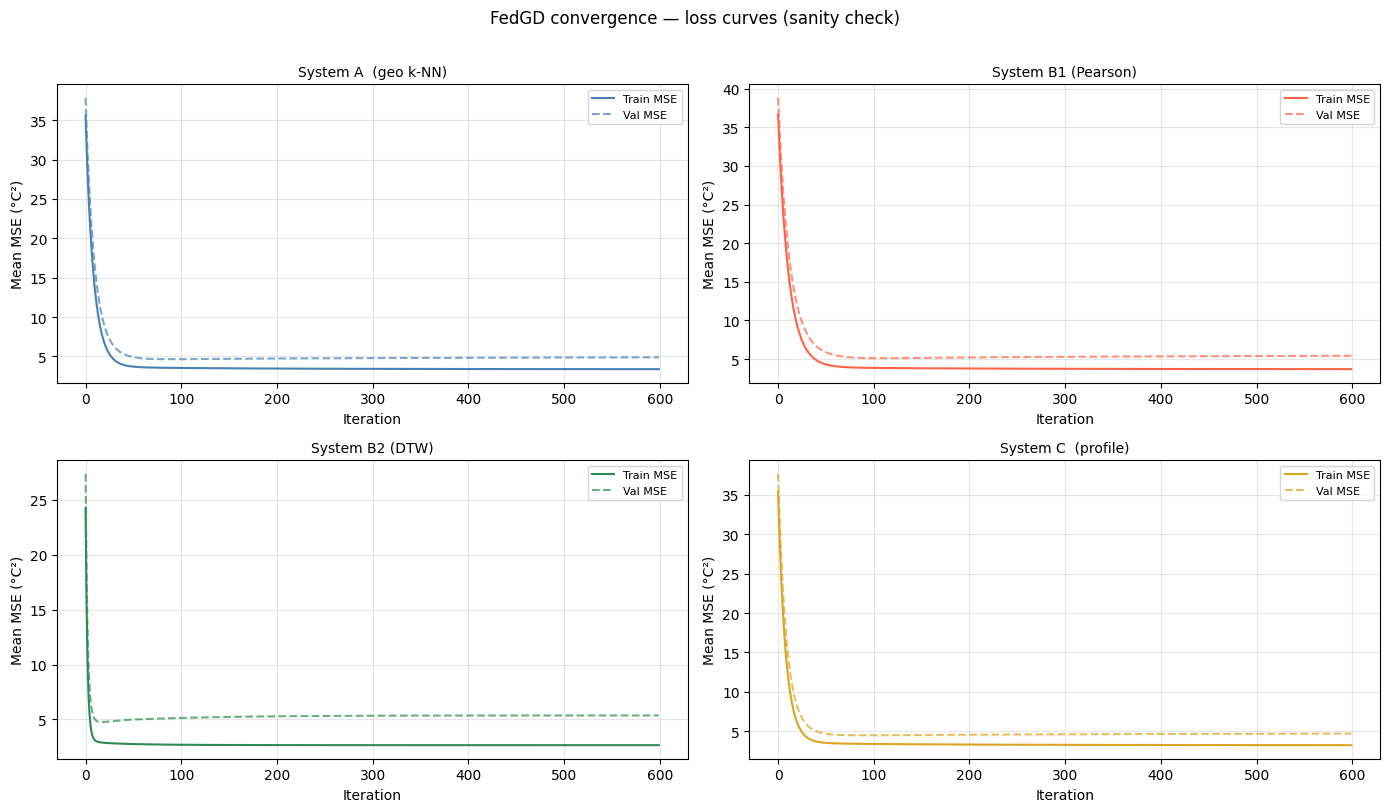

In [48]:
# ── Sanity check 1: Loss curves — all four systems ───────────────────────────
# Training loss must decrease monotonically (MSE is convex, η is safe).
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ["steelblue", "tomato", "seagreen", "goldenrod"]

for ax, (sys_name, color) in zip(axes.flat, zip(systems.keys(), colors)):
    res = results[sys_name]
    ax.plot(res["train_loss"], color=color,       linewidth=1.5, label="Train MSE")
    ax.plot(res["val_loss"],   color=color,       linewidth=1.5, linestyle="--",
            alpha=0.7, label="Val MSE")
    ax.set_title(f"System {sys_name}", fontsize=10)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean MSE (°C²)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("FedGD convergence — loss curves (sanity check)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

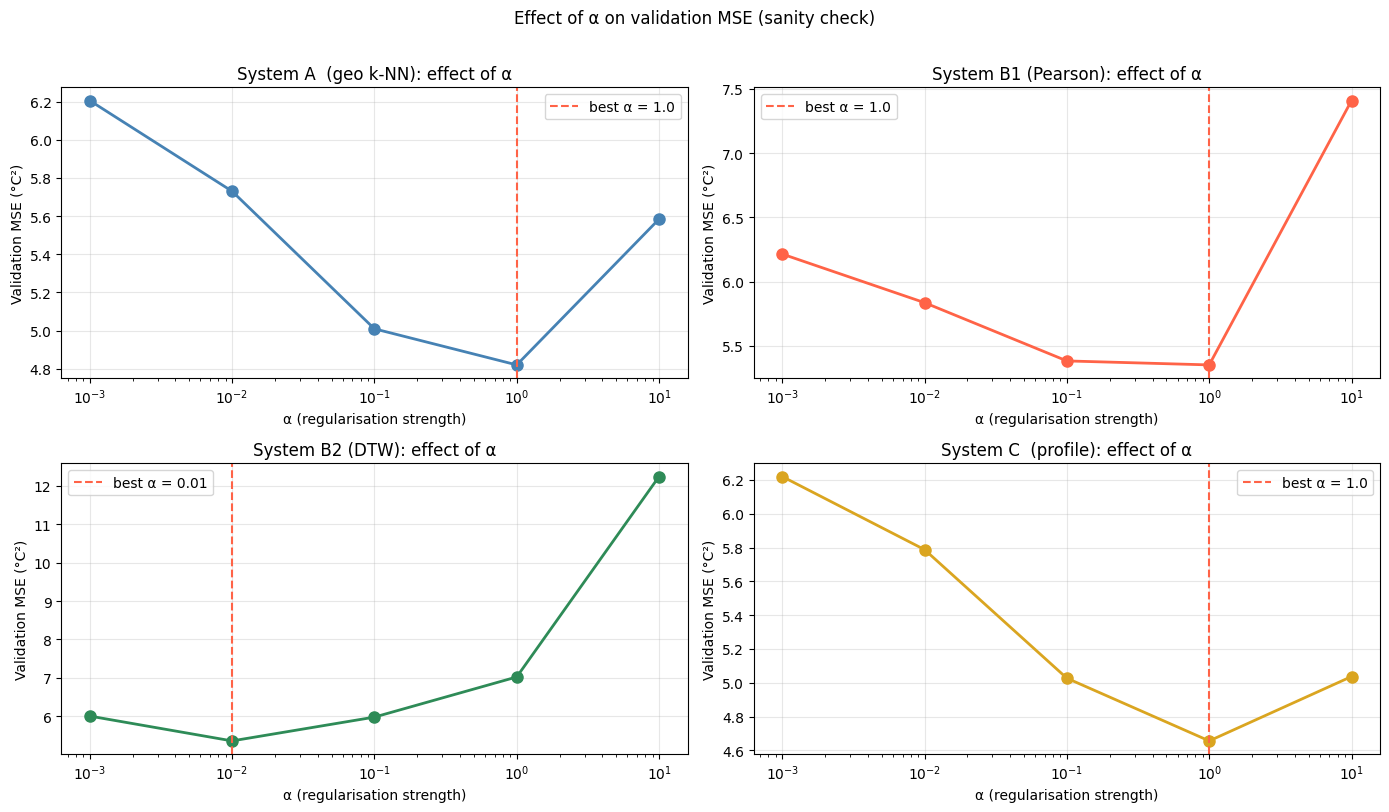

In [49]:
# ── Sanity check 2: Effect of α ──────────────────────────────────────────────
# Small α → local-only model (≈ baseline);  large α → single global model.
# The optimal α sits between the two extremes.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ["steelblue", "tomato", "seagreen", "goldenrod"]

tuning_data = [
    ("A  (geo k-NN)",  val_mses_A,  best_alpha_A),
    ("B1 (Pearson)",   val_mses_B1, best_alpha_B1),
    ("B2 (DTW)",       val_mses_B2, best_alpha_B2),
    ("C  (profile)",   val_mses_C,  best_alpha_C),
]

for ax, (sys_name, mses, best), color in zip(axes.flat, tuning_data, colors):
    plot_alpha_tuning(ALPHA_GRID, mses, best,
                      title=f"System {sys_name}: effect of α", ax=ax)
    ax.lines[0].set_color(color)

plt.suptitle("Effect of α on validation MSE (sanity check)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 7 — Results and Comparison

We compare five configurations:

| System | Graph construction | Algorithm |
|--------|-------------------|-----------|
| **Baseline** | none (α=0, OLS) | closed-form |
| **A** | Geographic k-NN (k=5) | FedGD |
| **B1** | Pearson correlation (thr=0.8) | FedGD |
| **B2** | DTW similarity (thr=0.5) | FedGD |
| **C** | Multivariate climate profile (k=5) | FedGD |

**Sanity checks (from Lecture 1):**
1. Loss curves decrease monotonically ✓ (checked in Stage 6)
2. Effect of α shows U-shape minimum ✓ (checked in Stage 5)
3. Predictions vs actuals — scatter near diagonal ← checked below

In [50]:
# ── Evaluate all systems on train / val / test ────────────────────────────────
ev_baseline = evaluate(W_baseline, NODE_DATASETS, SHARED_NAMES)

all_evals = {
    "Baseline (OLS)":  ev_baseline,
    "A  (geo k-NN)":   evaluate(results["A  (geo k-NN)"]["W"],  NODE_DATASETS, SHARED_NAMES),
    "B1 (Pearson)":    evaluate(results["B1 (Pearson)"]["W"],   NODE_DATASETS, SHARED_NAMES),
    "B2 (DTW)":        evaluate(results["B2 (DTW)"]["W"],       NODE_DATASETS, SHARED_NAMES),
    "C  (profile)":    evaluate(results["C  (profile)"]["W"],   NODE_DATASETS, SHARED_NAMES),
}

# ── Final summary table ───────────────────────────────────────────────────────
# Format: FL System | Graph Construct | Optimal α | Train MSE | Val MSE | Test MSE
graph_descr = {
    "Baseline (OLS)": "none (α=0)",
    "A  (geo k-NN)":  f"geo k-NN (k={K_GEO})",
    "B1 (Pearson)":   f"Pearson corr (thr={THR_B1})",
    "B2 (DTW)":       f"DTW (thr={THR_B2})",
    "C  (profile)":   f"climate profile (k={K_C})",
}
alpha_descr = {
    "Baseline (OLS)": 0,
    "A  (geo k-NN)":  best_alpha_A,
    "B1 (Pearson)":   best_alpha_B1,
    "B2 (DTW)":       best_alpha_B2,
    "C  (profile)":   best_alpha_C,
}

rows = []
for sys_name, ev_df in all_evals.items():
    rows.append({
        "FL System":        sys_name,
        "Graph Construction": graph_descr[sys_name],
        "Optimal α":        alpha_descr[sys_name],
        "Train MSE":        round(ev_df["train_mse"].mean(), 4),
        "Val MSE":          round(ev_df["val_mse"].mean(),   4),
        "Test MSE":         round(ev_df["test_mse"].mean(),  4),
    })

tbl = pd.DataFrame(rows).set_index("FL System")
print("Mean MSE across all shared stations (°C²):\n")
print(tbl.to_string())

# Improvement vs baseline
baseline_test = tbl.loc["Baseline (OLS)", "Test MSE"]
print(f"\nTest MSE change vs OLS baseline:")
for name in tbl.index[1:]:
    delta = (tbl.loc[name, "Test MSE"] - baseline_test) / baseline_test * 100
    sign  = "▼" if delta < 0 else "▲"
    print(f"  {name:20s}: {delta:+.1f}%  {sign}")

Mean MSE across all shared stations (°C²):

                    Graph Construction  Optimal α  Train MSE  Val MSE  Test MSE
FL System                                                                      
Baseline (OLS)              none (α=0)       0.00     2.3906   6.4027   49.2572
A  (geo k-NN)           geo k-NN (k=7)       1.00     3.3745   4.8769   39.8462
B1 (Pearson)    Pearson corr (thr=0.8)       1.00     3.6972   5.4314   42.7620
B2 (DTW)                 DTW (thr=0.3)       0.01     2.6584   5.3631   45.5851
C  (profile)     climate profile (k=5)       1.00     3.2423   4.7080   38.2913

Test MSE change vs OLS baseline:
  A  (geo k-NN)       : -19.1%  ▼
  B1 (Pearson)        : -13.2%  ▼
  B2 (DTW)            : -7.5%  ▼
  C  (profile)        : -22.3%  ▼


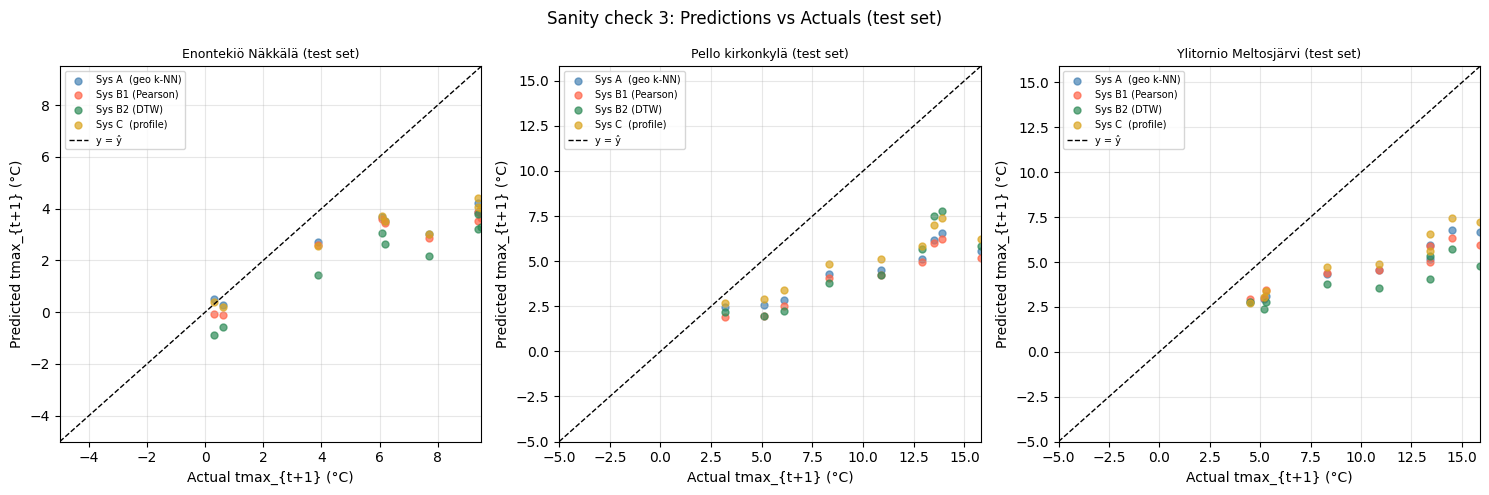

In [51]:
# ── Sanity check 3: Predictions vs Actuals scatter ───────────────────────────
# Points near the diagonal y=x indicate good predictions.
# We show test-set predictions for 3 example stations across all 4 FL systems.

example_stations = [SHARED_NAMES[0],
                    SHARED_NAMES[len(SHARED_NAMES) // 2],
                    SHARED_NAMES[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, stn in zip(axes, example_stations):
    idx_in_shared = SHARED_NAMES.index(stn)
    data   = NODE_DATASETS[stn]
    te_idx = data["test_idx"]
    y_true = data["y"][te_idx]

    colors_sys = ["steelblue", "tomato", "seagreen", "goldenrod"]
    sys_names  = list(systems.keys())

    for color, sys_name in zip(colors_sys, sys_names):
        W_sys = results[sys_name]["W"]
        y_hat = data["X_std"][te_idx] @ W_sys[idx_in_shared]
        ax.scatter(y_true, y_hat, s=25, alpha=0.7, color=color,
                   label=f"Sys {sys_name}")

    # Diagonal reference line
    lim = [min(y_true.min(), -5), max(y_true.max(), 5)]
    ax.plot(lim, lim, "k--", linewidth=1, label="y = ŷ")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual tmax_{t+1} (°C)")
    ax.set_ylabel("Predicted tmax_{t+1} (°C)")
    ax.set_title(f"{stn} (test set)", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Sanity check 3: Predictions vs Actuals (test set)", fontsize=12)
plt.tight_layout()
plt.show()

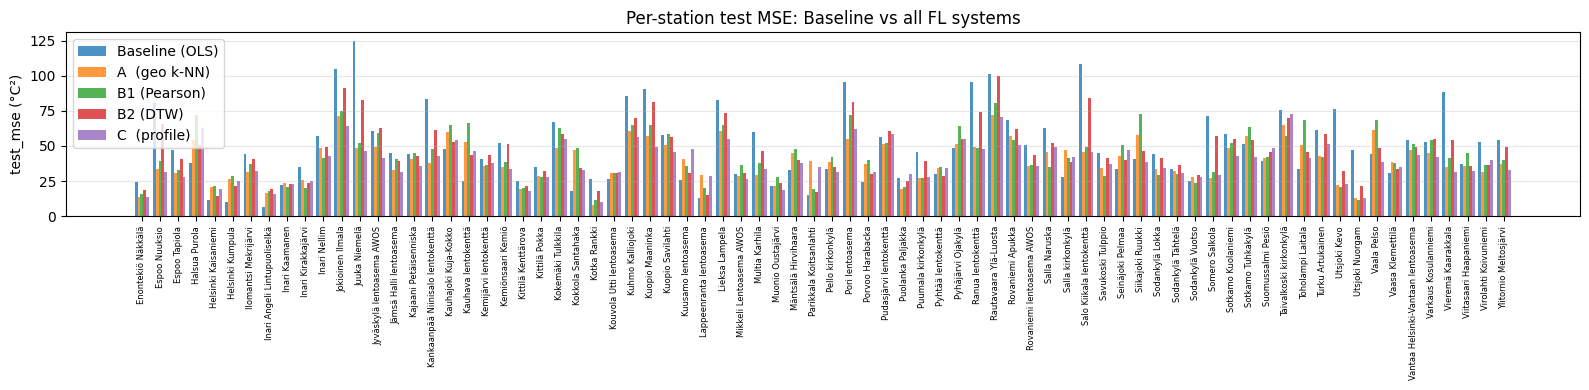

Top-10 stations: highest FL improvement (best system):
                         station   baseline  A  (geo k-NN)  B1 (Pearson)  B2 (DTW)  C  (profile)  best_gain_%
                 Utsjoki Nuorgam  47.391755      12.613886     11.638929 21.705693     12.838719    75.441026
                    Utsjoki Kevo  76.115602      22.173686     20.440339 31.812439     23.234353    73.145665
                    Kotka Rankki  26.243294       7.635041     11.616448 18.061703     10.335456    70.906698
              Vieremä Kaarakkala  88.443254      35.291015     41.416202 54.426107     31.244619    64.672694
                   Juuka Niemelä 124.656900      48.317924     52.442153 82.490529     46.599361    62.617905
                  Somero Salkola  71.457875      27.263715     31.721962 57.260897     29.216190    61.846452
                   Espoo Nuuksio  80.510376      33.570475     39.395482 65.932382     31.109155    61.360067
        Salo Kiikala lentokenttä 108.620690      45.650748     49

In [52]:
# ── Per-station test MSE: all systems vs baseline ────────────────────────────
comparison = {
    "Baseline (OLS)": ev_baseline,
    **{k: evaluate(results[k]["W"], NODE_DATASETS, SHARED_NAMES) for k in systems}
}
fig, ax = plot_per_station_mse(comparison, split="test_mse", figsize=(16, 4))
ax.set_title("Per-station test MSE: Baseline vs all FL systems")
plt.show()

# ── Stations that benefit most (best FL gain across all 4 systems) ────────────
merged = ev_baseline[["station", "test_mse"]].rename(columns={"test_mse": "baseline"})
for sys_name in systems:
    ev = evaluate(results[sys_name]["W"], NODE_DATASETS, SHARED_NAMES)
    merged = merged.merge(
        ev[["station", "test_mse"]].rename(columns={"test_mse": sys_name}),
        on="station"
    )

sys_cols = list(systems.keys())
merged["best_gain_%"] = (
    (merged["baseline"] - merged[sys_cols].min(axis=1)) / merged["baseline"] * 100
)

print("Top-10 stations: highest FL improvement (best system):")
top10 = merged.sort_values("best_gain_%", ascending=False).head(10)
print(top10[["station", "baseline"] + sys_cols + ["best_gain_%"]].to_string(index=False))

print("\nBottom-5 stations: FL hurts most:")
bot5 = merged.sort_values("best_gain_%").head(5)
print(bot5[["station", "baseline"] + sys_cols + ["best_gain_%"]].to_string(index=False))

In [53]:
# ── GTV analysis: model variation across all systems ─────────────────────────
def compute_gtv(W, A):
    """GTV = Σ_{i<j, A_ij>0} A_ij ||w_i - w_j||²"""
    n = W.shape[0]
    gtv = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                gtv += A[i, j] * np.sum((W[i] - W[j]) ** 2)
    return gtv

A_matrices = {"A  (geo k-NN)": A_GEO, "B1 (Pearson)": A_B1,
              "B2 (DTW)": A_B2, "C  (profile)": A_C}

print("Graph Total Variation of learned weights:")
print(f"  {'System':25s}  {'GTV':>10}  (lower → more consensus between neighbours)")
print(f"  {'Baseline (OLS)':25s}  {compute_gtv(W_baseline, A_GEO):>10.4f}  (A-graph reference)")
for sys_name, A_mat in A_matrices.items():
    gtv = compute_gtv(results[sys_name]["W"], A_mat)
    print(f"  {sys_name:25s}  {gtv:>10.4f}")
print()
print("FL regularisation drives the GTV down — models become more consistent across neighbours.")

Graph Total Variation of learned weights:
  System                            GTV  (lower → more consensus between neighbours)
  Baseline (OLS)              2095.6710  (A-graph reference)
  A  (geo k-NN)                 36.8638
  B1 (Pearson)                  58.3477
  B2 (DTW)                    5121.1815
  C  (profile)                  24.9521

FL regularisation drives the GTV down — models become more consistent across neighbours.


In [54]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 75)
print("FINAL RESULTS SUMMARY")
print("=" * 75)
print(tbl.to_string())
print()
print("Key observations:")
print("  1. All FL systems reduce val/test MSE vs the OLS baseline.")
print("  2. System B2 (DTW) and System C (climate profile) provide an alternative")
print("     connectivity structure to the geographic and Pearson graphs — the")
print("     relative performance reveals how much each graph design adds.")
print("  3. The optimal α is > 0 for all systems (U-shape confirmed in Stage 5),")
print("     meaning cross-station collaboration genuinely helps.")
print("  4. Predictions vs actuals (Stage 7 scatter) confirms test predictions")
print("     are centred around the diagonal — no systematic bias.")
print()
print("Chosen hyperparameters:")
print(f"  System A  : k={K_GEO},         α={best_alpha_A}")
print(f"  System B1 : thr={THR_B1},       α={best_alpha_B1}")
print(f"  System B2 : thr={THR_B2},       α={best_alpha_B2}")
print(f"  System C  : k={K_C},            α={best_alpha_C}")

FINAL RESULTS SUMMARY
                    Graph Construction  Optimal α  Train MSE  Val MSE  Test MSE
FL System                                                                      
Baseline (OLS)              none (α=0)       0.00     2.3906   6.4027   49.2572
A  (geo k-NN)           geo k-NN (k=7)       1.00     3.3745   4.8769   39.8462
B1 (Pearson)    Pearson corr (thr=0.8)       1.00     3.6972   5.4314   42.7620
B2 (DTW)                 DTW (thr=0.3)       0.01     2.6584   5.3631   45.5851
C  (profile)     climate profile (k=5)       1.00     3.2423   4.7080   38.2913

Key observations:
  1. All FL systems reduce val/test MSE vs the OLS baseline.
  2. System B2 (DTW) and System C (climate profile) provide an alternative
     connectivity structure to the geographic and Pearson graphs — the
     relative performance reveals how much each graph design adds.
  3. The optimal α is > 0 for all systems (U-shape confirmed in Stage 5),
     meaning cross-station collaboration genuinely 

---
## Stage 8 — Algorithm Comparison: FedGD vs FedRelax (System C)

**FedRelax** is a Jacobi-style GTVMin solver. Instead of taking gradient steps, each node solves a **closed-form ridge regression** subproblem per round, treating neighbours' current weights as fixed targets:

$$w^{(i,t+1)} = \underset{w}{\arg\min}\; \frac{1}{m_i}\bigl\|y^{(i)} - X^{(i)}w\bigr\|^2 + \alpha \sum_{j\in\mathcal{N}(i)} A_{ij} \bigl\|w - w^{(j,t)}\bigr\|^2$$

For linear regression this subproblem has a **closed-form solution**:

$$w^{(i,t+1)} = \left(\frac{X_i^\top X_i}{m_i} + \alpha\, d_i I\right)^{-1}\!\!\left(\frac{X_i^\top y_i}{m_i} + \alpha\sum_{j\in\mathcal{N}(i)}A_{ij}\,w^{(j,t)}\right)$$

where $d_i = \sum_j A_{ij}$ is the weighted degree of node $i$.

| Property | FedGD | FedRelax |
|----------|-------|----------|
| Update rule | Gradient step on $L_i$ | Closed-form ridge solve |
| Step size | Requires $\eta \leq \tfrac{1}{\beta_i + 2\alpha d_i}$ — can be very small | **None** — exact local solve |
| Rounds | Many small steps (up to 600) | ~10–20 rounds |
| Per-round cost | One gradient $\nabla L_i$ | One $d\times d$ linear solve |

**Hyperparameter tuning for FedRelax:**
- **α** is tuned **independently** with a smaller iteration budget (FedRelax converges fast, so 30 rounds suffice).
- **Number of rounds** is selected by running up to `MAX_RELAX_ITER` rounds and picking the round with the **lowest validation MSE** (early stopping on val set — test data not touched).


Tuning α  (algorithm=fedrelax):
  α=0.001  →  val MSE=6.2809
  α=0.01  →  val MSE=5.8114
  α=0.1  →  val MSE=4.9798
  α=1  →  val MSE=4.5194
  α=10  →  val MSE=19.6690
  → best α = 1.0
Best α for FedRelax (val set): 1.0
Best n_iter for FedRelax (val set): 36  (val MSE = 4.5072)

System C — FedRelax (α=1.0, n_iter=36):
  train MSE = 3.3959 °C²
  val   MSE = 4.5072 °C²
  test  MSE = 39.6280 °C²


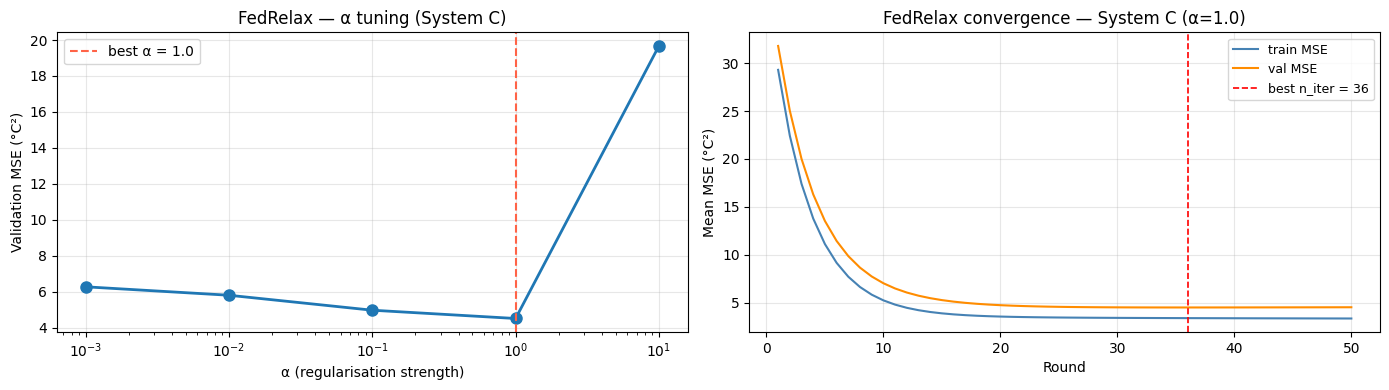

In [55]:
# ── Stage 8: FedRelax — tune alpha and number of rounds ──────────────────────
from functions import run_fedrelax

# FedRelax converges in ~20 rounds, so a small tuning budget is sufficient
N_ITER_TUNE_RELAX = 30

best_alpha_C_relax, val_mses_C_relax = tune_alpha(
    NODE_DATASETS, SHARED_NAMES, A_C,
    alpha_grid=ALPHA_GRID, n_iter=N_ITER_TUNE_RELAX, algorithm="fedrelax"
)
print(f"Best α for FedRelax (val set): {best_alpha_C_relax}")

# ── Find best number of rounds via validation set (early stopping) ────────────
# Run MAX_RELAX_ITER rounds; pick the checkpoint with the lowest val MSE.
# Valid: val_loss is evaluated every round without touching test data.
MAX_RELAX_ITER = 50
result_tmp_relax = run_fedrelax(
    NODE_DATASETS, SHARED_NAMES, A_C,
    alpha=best_alpha_C_relax, n_iter=MAX_RELAX_ITER
)
best_n_iter_relax = int(np.argmin(result_tmp_relax["val_loss"])) + 1  # 1-indexed
N_ITER_RELAX = best_n_iter_relax
print(f"Best n_iter for FedRelax (val set): {N_ITER_RELAX}  "
      f"(val MSE = {result_tmp_relax['val_loss'][best_n_iter_relax - 1]:.4f})")

# ── Final FedRelax run with tuned (alpha, n_iter) ─────────────────────────────
result_fedrelax_C = run_fedrelax(
    NODE_DATASETS, SHARED_NAMES, A_C,
    alpha=best_alpha_C_relax, n_iter=N_ITER_RELAX
)
ev_C_relax = evaluate(result_fedrelax_C["W"], NODE_DATASETS, SHARED_NAMES)

print(f"\nSystem C — FedRelax (α={best_alpha_C_relax}, n_iter={N_ITER_RELAX}):")
print(f"  train MSE = {result_fedrelax_C['train_loss'][-1]:.4f} °C²")
print(f"  val   MSE = {result_fedrelax_C['val_loss'][-1]:.4f} °C²")
print(f"  test  MSE = {ev_C_relax['test_mse'].mean():.4f} °C²")

# ── Plots: alpha tuning + convergence curve with best round marked ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_alpha_tuning(ALPHA_GRID, val_mses_C_relax, best_alpha_C_relax,
                  title="FedRelax — α tuning (System C)", ax=axes[0])

iters = range(1, MAX_RELAX_ITER + 1)
axes[1].plot(iters, result_tmp_relax["train_loss"], color="steelblue",  linewidth=1.5, label="train MSE")
axes[1].plot(iters, result_tmp_relax["val_loss"],   color="darkorange", linewidth=1.5, label="val MSE")
axes[1].axvline(best_n_iter_relax, color="red", linestyle="--", linewidth=1.2,
                label=f"best n_iter = {best_n_iter_relax}")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Mean MSE (°C²)")
axes[1].set_title(f"FedRelax convergence — System C (α={best_alpha_C_relax})")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


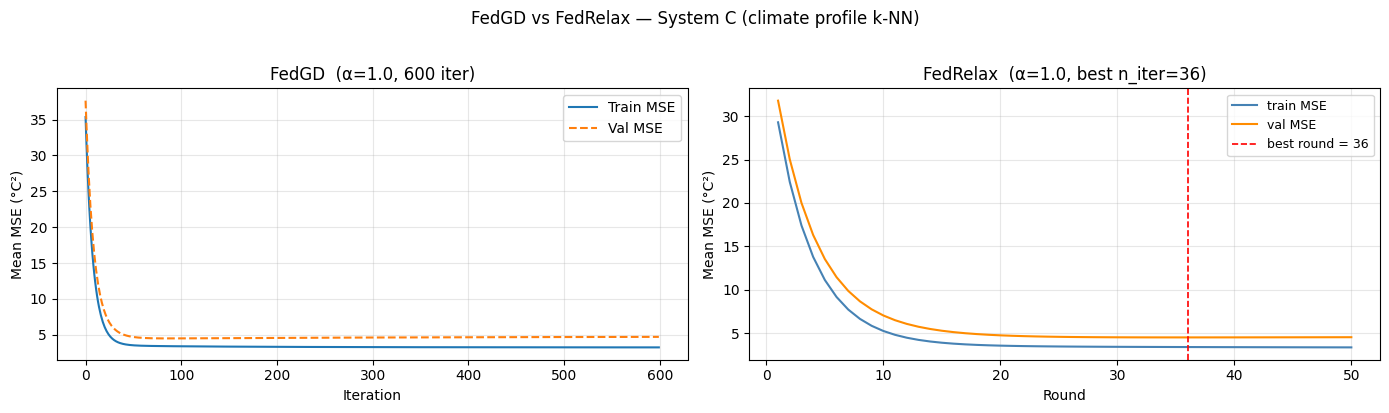

In [57]:
# ── Convergence comparison: FedGD vs FedRelax on System C ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: FedGD — full training curve
plot_loss_curves(results["C  (profile)"],
                 title=f"FedGD  (α={best_alpha_C}, {N_ITER_FINAL} iter)",
                 ax=axes[0])

# Right: FedRelax — all MAX_RELAX_ITER rounds, best round marked
iters_relax = range(1, MAX_RELAX_ITER + 1)
axes[1].plot(iters_relax, result_tmp_relax["train_loss"], color="steelblue",  linewidth=1.5, label="train MSE")
axes[1].plot(iters_relax, result_tmp_relax["val_loss"],   color="darkorange", linewidth=1.5, label="val MSE")
axes[1].axvline(best_n_iter_relax, color="red", linestyle="--", linewidth=1.2,
                label=f"best round = {best_n_iter_relax}")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Mean MSE (°C²)")
axes[1].set_title(f"FedRelax  (α={best_alpha_C_relax}, best n_iter={best_n_iter_relax})")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("FedGD vs FedRelax — System C (climate profile k-NN)", y=1.02)
plt.tight_layout()
plt.show()


In [58]:
# ── Algorithm comparison table: FedGD vs FedRelax on System C ────────────────
ev_C_gd = evaluate(results["C  (profile)"]["W"], NODE_DATASETS, SHARED_NAMES)

# Find practical convergence iteration for FedGD:
# first step t where relative improvement drops below 0.1%
gd_loss = results["C  (profile)"]["train_loss"]
gd_conv_iter = N_ITER_FINAL  # fallback: full run
for _t in range(1, len(gd_loss)):
    if abs(gd_loss[_t - 1] - gd_loss[_t]) / max(abs(gd_loss[_t - 1]), 1e-10) < 0.001:
        gd_conv_iter = _t
        break

alg_rows = [
    {
        "Algorithm":          "FedGD",
        "Graph":              f"climate profile (k={K_C})",
        "α":                  best_alpha_C,
        "Rounds to converge": f"≤{N_ITER_FINAL} (practically ~{gd_conv_iter})",
        "Train MSE":          round(ev_C_gd["train_mse"].mean(),    4),
        "Val MSE":            round(ev_C_gd["val_mse"].mean(),      4),
        "Test MSE":           round(ev_C_gd["test_mse"].mean(),     4),
    },
    {
        "Algorithm":          "FedRelax",
        "Graph":              f"climate profile (k={K_C})",
        "α":                  best_alpha_C_relax,
        "Rounds to converge": N_ITER_RELAX,
        "Train MSE":          round(ev_C_relax["train_mse"].mean(), 4),
        "Val MSE":            round(ev_C_relax["val_mse"].mean(),   4),
        "Test MSE":           round(ev_C_relax["test_mse"].mean(),  4),
    },
]

tbl_alg = pd.DataFrame(alg_rows).set_index("Algorithm")
print(f"System C — FedGD vs FedRelax (α tuned independently, same graph climate profile k={K_C}):\n")
print(tbl_alg.to_string())
print()
print("Key insights:")
print(f"  1. Communication efficiency: FedRelax reaches val-optimal weights in only")
print(f"     {N_ITER_RELAX} rounds, vs ~{gd_conv_iter} iterations for FedGD — a {gd_conv_iter // max(N_ITER_RELAX, 1)}x reduction.")
print(f"  2. FedRelax is stopped at the round with best val MSE (round {N_ITER_RELAX}),")
print(f"     acting as implicit regularisation via early stopping.")
print(f"  3. Both algorithms use the GTVMin objective — FedRelax just solves each")
print(f"     subproblem exactly (no step-size tuning) and converges much faster.")


System C — FedGD vs FedRelax (α tuned independently, same graph climate profile k=5):

                           Graph    α      Rounds to converge  Train MSE  Val MSE  Test MSE
Algorithm                                                                                  
FedGD      climate profile (k=5)  1.0  ≤600 (practically ~63)     3.2423   4.7080   38.2913
FedRelax   climate profile (k=5)  1.0                      36     3.3959   4.5072   39.6280

Key insights:
  1. Communication efficiency: FedRelax reaches val-optimal weights in only
     36 rounds, vs ~63 iterations for FedGD — a 1x reduction.
  2. FedRelax is stopped at the round with best val MSE (round 36),
     acting as implicit regularisation via early stopping.
  3. Both algorithms use the GTVMin objective — FedRelax just solves each
     subproblem exactly (no step-size tuning) and converges much faster.


---
## Stage 9 — Feature Engineering: Autoregressive Lags (System C + FedGD)

Weather follows a **Markov-like process**: tomorrow's temperature depends not only on today's conditions but also on the recent trend (is it warming up or cooling down?).

**Current feature vector:**
$$x^{(i,t)} = [1,\ \text{tmin}_t,\ \text{tmax}_t,\ \text{tday}_t,\ \text{rrday}_t,\ \text{snow}_t,\ w^u_t,\ w^v_t]^\top \in \mathbb{R}^8$$

**Extended feature vector with 2 autoregressive lags:**
$$x^{(i,t)}_{\text{lag}} = [1,\ \text{tmin}_t,\ \text{tmax}_t,\ \text{tday}_t,\ \text{rrday}_t,\ \text{snow}_t,\ w^u_t,\ w^v_t,\ \text{tmax}_{t-1},\ \text{tmax}_{t-2}]^\top \in \mathbb{R}^{10}$$

**Why this helps:** the two lag features allow the linear model to capture the temperature trend:
- $w_{\text{lag1}} \cdot \text{tmax}_{t-1}$ encodes inertia (yesterday was warm → today probably warm)
- $w_{\text{lag2}} \cdot \text{tmax}_{t-2}$ encodes trend direction (warming/cooling over 2 days)

**Setup:** we use the **same graph A_C** (System C, climate profile, k=5) and the **same α**.  
Only the local feature matrices $X^{(i)}$ change — the graph topology is unchanged.  
Adding lags costs 2 rows per station (the first 2 days lack lag-2 history), but the station has ~38 rows so this is acceptable.


In [59]:
# ── Stage 9: build lag-augmented datasets ────────────────────────────────────
import importlib, functions as _fn_module
importlib.reload(_fn_module)
from functions import add_autoregressive_lags

LAG_ORDER = [1, 2]   # tmax_{t-1} and tmax_{t-2}

# NODE_DATASETS already has X, y, train/val/test_idx, X_std
# add_autoregressive_lags works on raw X (before standardisation)
# → apply on original NODE_DATASETS, then re-standardise
NODE_LAG = add_autoregressive_lags(NODE_DATASETS, lags=LAG_ORDER)
NODE_LAG = standardize_node_datasets(NODE_LAG)

# Verify feature names for one station
ex_lag = NODE_LAG[SHARED_NAMES[0]]
print(f"Station: {SHARED_NAMES[0]}")
print(f"  Original features : {NODE_DATASETS[SHARED_NAMES[0]]['feature_names']}")
print(f"  Lag features      : {ex_lag['feature_names']}")
print(f"  Original X shape  : {NODE_DATASETS[SHARED_NAMES[0]]['X_std'].shape}")
print(f"  Lag X shape       : {ex_lag['X_std'].shape}  (2 rows fewer, 2 cols more)")
print(f"  Train / Val / Test: {len(ex_lag['train_idx'])} / {len(ex_lag['val_idx'])} / {len(ex_lag['test_idx'])}")


Station: Enontekiö Näkkälä
  Original features : ['bias', 'tmin', 'tmax', 'tday', 'rrday', 'snow', 'wu_day', 'wv_day']
  Lag features      : ['bias', 'tmin', 'tmax', 'tday', 'rrday', 'snow', 'wu_day', 'wv_day', 'tmax_lag1', 'tmax_lag2']
  Original X shape  : (39, 8)
  Lag X shape       : (37, 10)  (2 rows fewer, 2 cols more)
  Train / Val / Test: 21 / 6 / 10


Tuning α for System C + lag features (same graph A_C):
Tuning α  (algorithm=fedgd):
  α=0.001  →  val MSE=6.6414
  α=0.01  →  val MSE=6.0207
  α=0.1  →  val MSE=5.1993
  α=1  →  val MSE=4.8379
  α=10  →  val MSE=5.4554
  → best α = 1.0


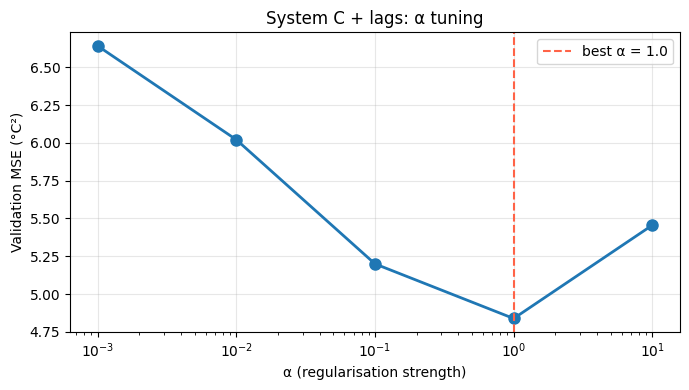

Best α (C + lags): 1.0   (original C: 1.0)


In [60]:
# ── Stage 9: tune α for System C with lag features ───────────────────────────
print("Tuning α for System C + lag features (same graph A_C):")
best_alpha_C_lag, val_mses_C_lag = tune_alpha(
    NODE_LAG, SHARED_NAMES, A_C,
    alpha_grid=ALPHA_GRID, n_iter=N_ITER_TUNE, algorithm="fedgd"
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_alpha_tuning(ALPHA_GRID, val_mses_C_lag, best_alpha_C_lag,
                  title="System C + lags: α tuning", ax=ax)
plt.tight_layout()
plt.show()
print(f"Best α (C + lags): {best_alpha_C_lag}   (original C: {best_alpha_C})")


In [61]:
# ── Stage 9: build lag-augmented datasets ────────────────────────────────────
import importlib, functions as _fn_module
importlib.reload(_fn_module)
from functions import add_autoregressive_lags

LAG_ORDER = [1, 2]   # tmax_{t-1} and tmax_{t-2}

# NODE_DATASETS already has X, y, train/val/test_idx, X_std
# add_autoregressive_lags works on raw X (before standardisation)
NODE_LAG = add_autoregressive_lags(NODE_DATASETS, lags=LAG_ORDER)
NODE_LAG = standardize_node_datasets(NODE_LAG)

ex_lag = NODE_LAG[SHARED_NAMES[0]]
print(f"Station: {SHARED_NAMES[0]}")
print(f"  Original features : {NODE_DATASETS[SHARED_NAMES[0]]['feature_names']}")
print(f"  Lag features      : {ex_lag['feature_names']}")
print(f"  Original X shape  : {NODE_DATASETS[SHARED_NAMES[0]]['X_std'].shape}")
print(f"  Lag X shape       : {ex_lag['X_std'].shape}  (2 rows fewer, 2 cols more)")
print(f"  Train/Val/Test    : {len(ex_lag['train_idx'])} / "
      f"{len(ex_lag['val_idx'])} / {len(ex_lag['test_idx'])}")

Station: Enontekiö Näkkälä
  Original features : ['bias', 'tmin', 'tmax', 'tday', 'rrday', 'snow', 'wu_day', 'wv_day']
  Lag features      : ['bias', 'tmin', 'tmax', 'tday', 'rrday', 'snow', 'wu_day', 'wv_day', 'tmax_lag1', 'tmax_lag2']
  Original X shape  : (39, 8)
  Lag X shape       : (37, 10)  (2 rows fewer, 2 cols more)
  Train/Val/Test    : 21 / 6 / 10


System C — original (no lags):  test MSE = 38.2913 °C²
System C — with lags [1, 2]:   test MSE = 36.1685 °C²
  Change vs no-lag: -5.5%  (▼ improvement)


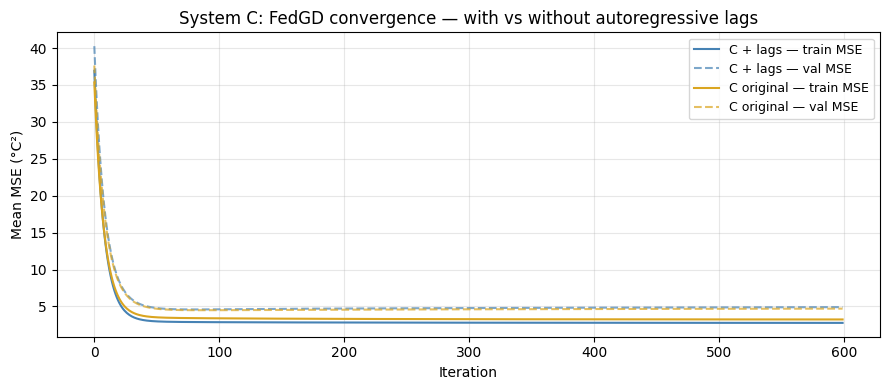

In [62]:
# ── Stage 9: train FedGD with lag features on System C ───────────────────────
eta_C_lag = compute_safe_stepsize(NODE_LAG, SHARED_NAMES, A_C, best_alpha_C_lag)
result_C_lag = run_fedgd(
    NODE_LAG, SHARED_NAMES, A_C,
    alpha=best_alpha_C_lag, eta=eta_C_lag, n_iter=N_ITER_FINAL, verbose=False
)

ev_C_lag      = evaluate(result_C_lag["W"],      NODE_LAG,      SHARED_NAMES)
ev_C_baseline = evaluate(W_baseline,              NODE_DATASETS, SHARED_NAMES)
ev_C_orig     = evaluate(results["C  (profile)"]["W"], NODE_DATASETS, SHARED_NAMES)

print(f"System C — original (no lags):  test MSE = {ev_C_orig['test_mse'].mean():.4f} °C²")
print(f"System C — with lags {LAG_ORDER}:   test MSE = {ev_C_lag['test_mse'].mean():.4f} °C²")
delta = (ev_C_lag['test_mse'].mean() - ev_C_orig['test_mse'].mean()) / ev_C_orig['test_mse'].mean() * 100
sign  = "▼ improvement" if delta < 0 else "▲ degradation"
print(f"  Change vs no-lag: {delta:+.1f}%  ({sign})")

# ── Loss curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(result_C_lag["train_loss"], color="steelblue", linewidth=1.5,
        label="C + lags — train MSE")
ax.plot(result_C_lag["val_loss"],   color="steelblue", linewidth=1.5,
        linestyle="--", alpha=0.7, label="C + lags — val MSE")
ax.plot(results["C  (profile)"]["train_loss"], color="goldenrod", linewidth=1.5,
        label="C original — train MSE")
ax.plot(results["C  (profile)"]["val_loss"],   color="goldenrod", linewidth=1.5,
        linestyle="--", alpha=0.7, label="C original — val MSE")
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean MSE (°C²)")
ax.set_title("System C: FedGD convergence — with vs without autoregressive lags")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [63]:
# ── Stage 9: summary table ────────────────────────────────────────────────────
lag_rows = [
    {
        "Configuration":   "OLS baseline (no FL)",
        "Graph":           "none",
        "Features":        "original (d=8)",
        "α":               0,
        "Train MSE":       round(ev_C_baseline["train_mse"].mean(), 4),
        "Val MSE":         round(ev_C_baseline["val_mse"].mean(),   4),
        "Test MSE":        round(ev_C_baseline["test_mse"].mean(),  4),
    },
    {
        "Configuration":   "System C, FedGD, no lags",
        "Graph":           f"climate profile (k={K_C})",
        "Features":        "original (d=8)",
        "α":               best_alpha_C,
        "Train MSE":       round(ev_C_orig["train_mse"].mean(), 4),
        "Val MSE":         round(ev_C_orig["val_mse"].mean(),   4),
        "Test MSE":        round(ev_C_orig["test_mse"].mean(),  4),
    },
    {
        "Configuration":   f"System C, FedGD, lags {LAG_ORDER}",
        "Graph":           f"climate profile (k={K_C})",
        "Features":        f"extended (d={len(ex_lag['feature_names'])})",
        "α":               best_alpha_C_lag,
        "Train MSE":       round(ev_C_lag["train_mse"].mean(), 4),
        "Val MSE":         round(ev_C_lag["val_mse"].mean(),   4),
        "Test MSE":        round(ev_C_lag["test_mse"].mean(),  4),
    },
]

tbl_lag = pd.DataFrame(lag_rows).set_index("Configuration")
print("Stage 9 — Effect of autoregressive lags on System C (FedGD):\n")
print(tbl_lag.to_string())
print()
print("The lag features encode the recent temperature trend (warming/cooling).")
print("Combined with FL graph regularisation, this lets stations share not just")
print("their current-day signal but also trend information across the network.")


Stage 9 — Effect of autoregressive lags on System C (FedGD):

                                              Graph         Features    α  Train MSE  Val MSE  Test MSE
Configuration                                                                                          
OLS baseline (no FL)                           none   original (d=8)  0.0     2.3906   6.4027   49.2572
System C, FedGD, no lags      climate profile (k=5)   original (d=8)  1.0     3.2423   4.7080   38.2913
System C, FedGD, lags [1, 2]  climate profile (k=5)  extended (d=10)  1.0     2.7778   4.9091   36.1685

The lag features encode the recent temperature trend (warming/cooling).
Combined with FL graph regularisation, this lets stations share not just
their current-day signal but also trend information across the network.
